In [1]:
import csv
import os
import pathlib

from matplotlib import pyplot as plt

In [2]:
path_latencies = pathlib.PurePath('outputs', 'links_latencies')

keys = set()
with open(path_latencies / min(os.listdir(path_latencies)), 'r') as f:
    reader = csv.DictReader(f)
    for row in reader:
        if row['ip_version'] == '4':
            keys.add((row['source_id'], row['target_id'], row['ip_version']))

time_series = {key: [] for key in keys}
for path_latencies_csv in list(sorted(os.listdir(path_latencies))):
    if not '20260407060000.json' <= path_latencies_csv <= '20260408180000.json':
        continue
    with open(path_latencies / path_latencies_csv, 'r') as f:
        values_to_add = {}
        reader = csv.DictReader(f)
        for row in reader:
            values_to_add[row['source_id'], row['target_id'], row['ip_version']] = float(row['latency'])
    values_to_add = {
        (source, target, ip_version): latency + values_to_add[target, source, ip_version]
        for (source, target, ip_version), latency in values_to_add.items()
        if source < target and ip_version == '4' and (target, source, ip_version) in values_to_add
    }

    for key in keys:
        if key in values_to_add:
            time_series[key].append(values_to_add[key])
        else:
            time_series[key].append(None)

In [3]:
def score_time_series(xs):
    # Just a naive implementation for now
    xs = [x for x in xs if x is not None]
    if xs:
        return max(xs) - min(xs)
    else:
        return 0.

sorted_keys = [
    key
    for _, key in sorted([
        (score_time_series(xs), key)
        for key, xs in time_series.items()
    ], reverse=True)
]

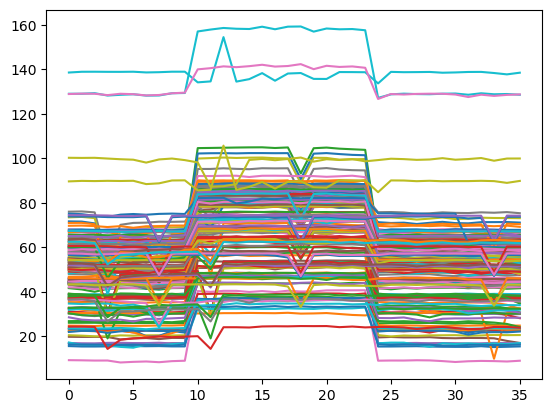

In [4]:
for key in sorted_keys[:200]:
    plt.plot(list(range(len(time_series[key]))), time_series[key])
plt.show()